 # HỆ CHẨN ĐOÁN BỆNH TIM — Intelligent System đầu tiên

 **Môn học: Intelligent System Development — Assignment 01**

 *Hệ thống phân loại Traditional ML: từ dữ liệu tim mạch đến một ứng dụng dự đoán*

 ---

 ## 0. Môi trường & Reproducibility (R14)

 Notebook này chạy end-to-end từ đầu đến cuối. Thông tin môi trường:

 | Thành phần | Giá trị |
 |---|---|
 | Python | 3.14 (Anaconda) |
 | scikit-learn | 1.9.0 |
 | pandas / numpy | 3.0.3 / 2.4.6 |
 | matplotlib / seaborn | 3.11.0 / 0.13.2 |
 | Dataset | `data/heart_cleveland.csv` (đã tải về local — chạy offline) |
 | Random seed | Cố định `RANDOM_STATE = 42` ở mọi nơi có tính ngẫu nhiên |

 Mọi cell được chạy tuần tự; không có cell nào phụ thuộc trạng thái thủ công.

 ## 1. System and Problem Definition (R2)

 ### 1.1 Định nghĩa hệ thống (System Statement — yêu cầu bắt buộc của đề)

 > Hệ thống được phát triển là một **hệ hỗ trợ sàng lọc bệnh tim** nhận các chỉ số tim mạch
 > đo lường được của một bệnh nhân (tuổi, giới tính, loại đau ngực, huyết áp, cholesterol,
 > nhịp tim tối đa, kết quả điện tâm đồ, số mạch vành chính bị hẹp, thalassemia...), **biểu diễn**
 > chúng thành một feature vector số học $x \in \mathbb{R}^{13}$, dùng model học từ dữ liệu
 > của 303 bệnh nhân để **dự đoán xác suất bệnh nhân có bị hẹp động mạch vành** (bệnh tim)
 > hay không, và **hỗ trợ quyết định** của nhân viên y tế: bệnh nhân nào cần được ưu tiên
 > chẩn đoán chuyên sâu hơn.

 Trả lời 6 câu hỏi định nghĩa hệ thống (mục 3 đề bài):

 | # | Câu hỏi | Trả lời |
 |---|---|---|
 | 1 | Vấn đề thực nào được giải? | Sàng lọc ban đầu bệnh tim (hẹp động mạch vành) từ chỉ số đo lường — hỗ trợ ưu tiên khám sâu |
 | 2 | Hệ thống nhận thông tin gì? | 13 chỉ số tim mạch của một bệnh nhân (dạng bảng) |
 | 3 | Biểu diễn nội bộ? | Feature vector $x \in \mathbb{R}^{13}$ sau encode + chuẩn hóa |
 | 4 | Model học gì? | Quan hệ ánh xạ chỉ số → có/không bệnh tim $\hat{y} = f_\theta(x)$ |
 | 5 | Quyết định/dự đoán? | Nhị phân: 0 (không bệnh) / 1 (có bệnh) + xác suất |
 | 6 | Ai dùng dự đoán? | Nhân viên y tế/phòng khám — làm cơ sở sàng lọc, KHÔNG thay thế chẩn đoán bác sĩ |

 ### 1.2 Formal problem statement (một câu — yêu cầu mục 10 đề)

 > **Given the 13-dimensional feature vector of diagnostic measurements, predict whether the patient has heart disease (class 1) or not (class 0).**

 $$D = \{(x_i, y_i)\}_{i=1}^{303}, \quad x_i \in \mathbb{R}^{13}, \; y_i \in \{0, 1\}, \quad \hat{y} = f_\theta(x)$$

 Đây là bài toán **binary classification** vì target là nhãn phân loại 2 lớp.

 ## 2. Intelligent System Diagram (R2)

 Sơ đồ hệ thống theo abstraction: **Environment → Input → Representation → Model → Decision → Output**

 ```
  ┌─────────────────┐   ┌──────────────┐   ┌───────────────────┐   ┌─────────────┐   ┌──────────────┐
  │ ENVIRONMENT     │   │ INPUT        │   │ REPRESENTATION    │   │ ML MODEL    │   │ OUTPUT       │
  │ Bệnh nhân đến   │──▶│ 13 chỉ số    │──▶│ Feature vector    │──▶│ Random      │──▶│ Dự đoán lớp  │
  │ phòng khám,     │   │ tim mạch đo  │   │ x ∈ R^13          │   │ Forest      │   │ + xác suất   │
  │ đo chỉ số       │   │ được         │   │ (encode + scale)  │   │ (learned)   │   │ bệnh tim     │
  └─────────────────┘   └──────────────┘   └───────────────────┘   └─────────────┘   └──────┬───────┘
         ▲                                                                                │
         │                    ┌────────────────────────────────────────────────┐         │
         └───────── feedback ─│ USER: nhân viên y tế dùng kết quả sàng lọc,   │◀────────┘
                              │ quyết định khám sâu → dữ liệu mới (A2+)        │
                              └────────────────────────────────────────────────┘
 ```

 Mapping sang khung Slide 01:

 | Slide 01 concept | Realization trong hệ này | Evidence |
 |---|---|---|
 | Intelligence | Predictive capability | Dự đoán bệnh tim cho bệnh nhân mới |
 | Intelligent system | Data + representation + model + application | Sơ đồ trên + web app Phần 3 |
 | External information | Dataset/observations | 303 bản ghi Cleveland (mục 3–4) |
 | Internal representation | Feature vector | Bảng feature + $X$ (mục 5) |
 | Learning | Training traditional ML | 4 model (mục 10–13) |
 | Decision | Prediction $\hat{y}$ | Model output + ngưỡng 0.5 |
 | Action/application | Small application | Streamlit app deploy HF Spaces |
 | Development | Experiment, evaluate, improve | 3 experiments (mục 15–17) |

 ### Import thư viện + cấu hình chung

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import sys

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc, RocCurveDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
sns.set_palette("Set2")

print("Python:", sys.version.split()[0])
print("sklearn:", __import__("sklearn").__version__)
print("pandas:", pd.__version__, "| numpy:", np.__version__)

Python: 3.14.6
sklearn: 1.9.0
pandas: 3.0.3 | numpy: 2.4.6


 ## 3. Dataset Source (R1)

 | Mục | Thông tin |
 |---|---|
 | **Tên dataset** | Heart Disease Data Set — bản **processed.cleveland** |
 | **Nguồn** | UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/45/heart+disease |
 | **Citations** | Janosi, A., Steinbrunn, W., Pfisterer, M., Detrano, R. (1988). *International Application of a New Probability Algorithm for the Diagnosis of Coronary Artery Disease.* |
 | **Bản dùng ở đây** | Đã tải về `data/heart_cleveland.csv` — chạy offline, đảm bảo reproducible |
 | **Số quan sát** | 303 bệnh nhân |
 | **Số feature** | 13 (dùng trong mô hình) + 1 target gốc `num` |

 Đây là dataset y khoa **thật** (bệnh nhân thực tại 4 trung tâm y tế, bản Cleveland của ĐH Cleveland Clinic). Đề bài Slide 67 nói *"Do not simply reproduce Lee's diabetes example"* — diabetes chỉ là scaffold; dataset của sinh viên phải khác. Heart Disease UCI là lựa chọn phù hợp: cùng dạng structured medical data, khác hoàn toàn về bài toán (tim mạch vs chuyển hóa).

In [2]:
df = pd.read_csv("../data/heart_clean.csv")
print(f"Kích thước: {df.shape[0]} quan sát x {df.shape[1]} cột (13 feature + 1 target nhị phân)")
df.head()

Kích thước: 303 quan sát x 14 cột (13 feature + 1 target nhị phân)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


 ## 4. Dataset Description (R1)

 Trả lời 10 câu hỏi bắt buộc (mục 7 đề bài):

 | # | Câu hỏi | Trả lời |
 |---|---|---|
 | 1 | Hiện tượng thực nào được biểu diễn? | Tình trạng hẹp động mạch vành của bệnh nhân đến khám |
 | 2 | Một quan sát là gì? | **Một bệnh nhân** với 13 chỉ số tim mạch tại thời điểm nhập viện |
 | 3 | Features là gì? | 13 chỉ số: tuổi, giới tính, đau ngực, huyết áp, cholesterol, đường huyết, ECG, nhịp tim max, đau thắt khi gắng sức, oldpeak, slope, ca, thal (chi tiết mục 5) |
 | 4 | Target là gì? | `num` gốc 0–4 → quy về nhị phân: 0 = không bệnh, 1–4 = có bệnh tim |
 | 5 | Target numerical hay categorical? | **Categorical** (nhị phân) |
 | 6 | Regression hay Classification? | **Binary Classification** |
 | 7 | Số quan sát? | 303 |
 | 8 | Số features? | 13 |
 | 9 | Features numerical? | 6: `age, trestbps, chol, thalach, oldpeak, ca` |
 | 10 | Features categorical? | 7: `sex, cp, fbs, restecg, exang, slope, thal` |

In [3]:
print("Kiểu dữ liệu từng cột:")
print(df.dtypes)
print()
print("Tổng giá trị thiếu:", df.isna().sum().sum())

Kiểu dữ liệu từng cột:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Tổng giá trị thiếu: 0


 **Tiền xử lý đã thực hiện khi dựng `heart_clean.csv`** (tái lập được, xem `README.md`):

 1. **Xử lý dữ liệu thiếu:** bản gốc có `ca` thiếu 4 mẫu, `thal` thiếu 2/303 (~2%) — em chọn **median imputation** theo từng cột (không bị kéo bởi outlier so với mean, giữ nguyên phân phối chính; phương án bỏ hàng sẽ mất ~2% dữ liệu y khoa quý);
 2. **Dựng target nhị phân:** `num` gốc 0–4 → `target = 1` nếu `num > 0` (có bệnh tim), ngược lại `0` — theo quy ước chuẩn của literature về dataset này (50% diameter narrowing).

In [4]:
print("Phân bố target nhị phân:")
print(df["target"].value_counts())
print(f"\nTỷ lệ lớp 1 (có bệnh): {df['target'].mean():.1%}")

Phân bố target nhị phân:
target
0    164
1    139
Name: count, dtype: int64

Tỷ lệ lớp 1 (có bệnh): 45.9%


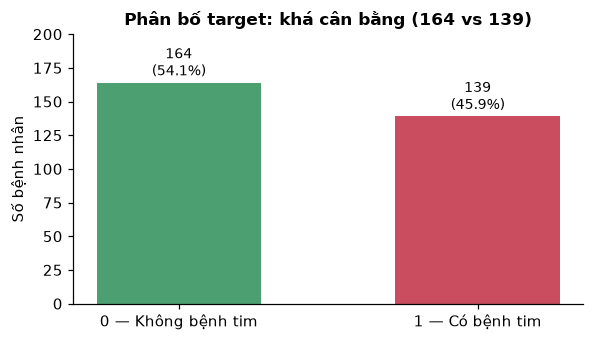

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
counts = df["target"].value_counts().sort_index()
bars = ax.bar(["0 — Không bệnh tim", "1 — Có bệnh tim"], counts.values,
              color=["#4c9f70", "#c94c5f"], width=0.55)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f"{v}\n({v/len(df):.1%})",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Số bệnh nhân")
ax.set_title("Phân bố target: khá cân bằng (164 vs 139)")
ax.set_ylim(0, 200)
plt.tight_layout(); plt.savefig("../figures/heart_01_target_dist.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích biểu đồ — Phân bố target:** Dataset có 164 bệnh nhân khỏe (54.1%) và 139 mắc bệnh tim (45.9%) — tỷ lệ gần cân bằng (không nghiêng nặng như nhiều dataset y khoa). Điều này có 2 hệ quả: (1) baseline "đoán lớp đa số" chỉ đạt ~54%, khá yếu — model học được có nhiều dư địa cải thiện; (2) accuracy là metric khá đáng tin ở đây, nhưng vẫn báo cáo đủ Precision/Recall/F1 vì chi phí bỏ sót người bệnh (FN) cao hơn báo giả (FP) trong y tế.

 ## 5. Data Representation (R3)

 ### 5.1 Feature table — 13 feature của hệ thống

 | Feature | Type | Representation | Meaning (nghĩa y khoa) |
 |---|---|---|---|
 | `age` | Numerical | Real value (năm) | Tuổi bệnh nhân |
 | `sex` | Categorical (binary) | 1 = nam, 0 = nữ | Giới tính |
 | `cp` | Categorical (4 giá trị) | 1–4 (không thứ tự) | Loại đau ngực: 1=typical angina, 2=atypical angina, 3=non-anginal, 4=asymptomatic |
 | `trestbps` | Numerical | Real (mm Hg) | Huyết áp tâm thu khi nghỉ |
 | `chol` | Numerical | Real (mg/dl) | Cholesterol huyết thanh |
 | `fbs` | Categorical (binary) | 1/0 | Đường huyết lúc đói > 120 mg/dl |
 | `restecg` | Categorical (3 giá trị) | 0–2 | Kết quả ECG khi nghỉ (0=bt, 1=bất thường ST-T, 2=phì đại thất trái) |
 | `thalach` | Numerical | Real (bpm) | Nhịp tim tối đa đạt được |
 | `exang` | Categorical (binary) | 1/0 | Đau thắt ngực do gắng sức |
 | `oldpeak` | Numerical | Real | Sự giảm đoạn ST do tập luyện so với nghỉ |
 | `slope` | Categorical (3 giá trị) | 0–2 | Độ dốc đoạn ST lúc tập tối đa |
 | `ca` | Numerical (đếm) | 0–3 | Số mạch vành chính bị nhuộm màu (fluoroscopy) |
 | `thal` | Categorical (3 giá trị) | 3/6/7 | Thalassemia: 3=bt, 6=fixed defect, 7=reversible defect |

 ### 5.2 Ba tầng representation (yêu cầu mục 8 đề)

 $$\text{Raw feature} \neq \text{Encoded feature} \neq \text{Model input}$$

 - **Raw**: `cp = 2` là *nhãn phân loại*, không phải "số 2 lớn gấp đôi số 1" — khoảng cách số học giữa 1..4 vô nghĩa;
 - **Encoded**: one-hot encoding tách `cp` thành 4 cột nhị phân `cp_1..cp_4` (loại giả định thứ tự sai);
 - **Model input**: feature số được standardize ($z = (x-\mu)/\sigma$) để các model nhạy với scale (KNN, SVM, LR) không bị đặc trưng thang lớn (chol ~ 200–500) áp đảo đặc trưng thang nhỏ (oldpeak ~ 0–6).

 > **Raw feature ≠ Encoded feature ≠ Model input** — chính là câu chốt của mục 8 đề bài.

In [6]:
# ==== Constructing the representation ====
feature_cols = [c for c in df.columns if c != "target"]
X_raw = df[feature_cols].copy()
y = df["target"].copy()

# Categorical features theo tài liệu UCI -> one-hot encode
CATEGORICAL = ["cp", "restecg", "slope", "thal", "sex", "fbs", "exang"]
NUMERICAL = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

X_encoded = pd.get_dummies(X_raw, columns=CATEGORICAL, prefix=CATEGORICAL)
# giữ thứ tự cột ổn định để reproduce + dùng cho app
ENC_COLS = list(X_encoded.columns)
print(f"Raw representation:  X_raw ∈ R^{X_raw.shape[1]}  ({X_raw.shape[0]} quan sát)")
print(f"Encoded representation: X_enc ∈ R^{X_encoded.shape[1]} (one-hot tách categorical)")
print("\nCác cột sau one-hot:")
print(ENC_COLS)
X_encoded.head(3)

Raw representation:  X_raw ∈ R^13  (303 quan sát)
Encoded representation: X_enc ∈ R^25 (one-hot tách categorical)

Các cột sau one-hot:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0', 'sex_0.0', 'sex_1.0', 'fbs_0.0', 'fbs_1.0', 'exang_0.0', 'exang_1.0']


,age,trestbps,chol,thalach,oldpeak,ca,cp_1.0,cp_2.0,cp_3.0,cp_4.0,...,slope_3.0,thal_3.0,thal_6.0,thal_7.0,sex_0.0,sex_1.0,fbs_0.0,fbs_1.0,exang_0.0,exang_1.0
0,63.0,145.0,233.0,150.0,2.3,0.0,True,False,False,False,...,True,False,True,False,False,True,False,True,True,False
1,67.0,160.0,286.0,108.0,1.5,3.0,False,False,False,True,...,False,True,False,False,False,True,True,False,False,True
2,67.0,120.0,229.0,129.0,2.6,2.0,False,False,False,True,...,False,False,False,True,False,True,True,False,False,True


 ## 6. Feature and Target Analysis (R4)

 Phân tích ý nghĩa + mối quan hệ của các feature trước khi dựng mô hình. Câu hỏi định hướng:

 1. Phân phối từng feature numerical có gì đặc biệt (outlier, skew)?
 2. Feature nào phân biệt được 2 lớp target?
 3. Feature nào tương quan mạnh với nhau (redundant)?

In [7]:
desc = df[NUMERICAL].describe().T.round(1)
desc["skew"] = df[NUMERICAL].skew().round(2)
desc

,count,mean,std,min,25%,50%,75%,max,skew
age,303.0,54.4,9.0,29.0,48.0,56.0,61.0,77.0,-0.21
trestbps,303.0,131.7,17.6,94.0,120.0,130.0,140.0,200.0,0.71
chol,303.0,246.7,51.8,126.0,211.0,241.0,275.0,564.0,1.14
thalach,303.0,149.6,22.9,71.0,133.5,153.0,166.0,202.0,-0.54
oldpeak,303.0,1.0,1.2,0.0,0.0,0.8,1.6,6.2,1.27
ca,303.0,0.7,0.9,0.0,0.0,0.0,1.0,3.0,1.21


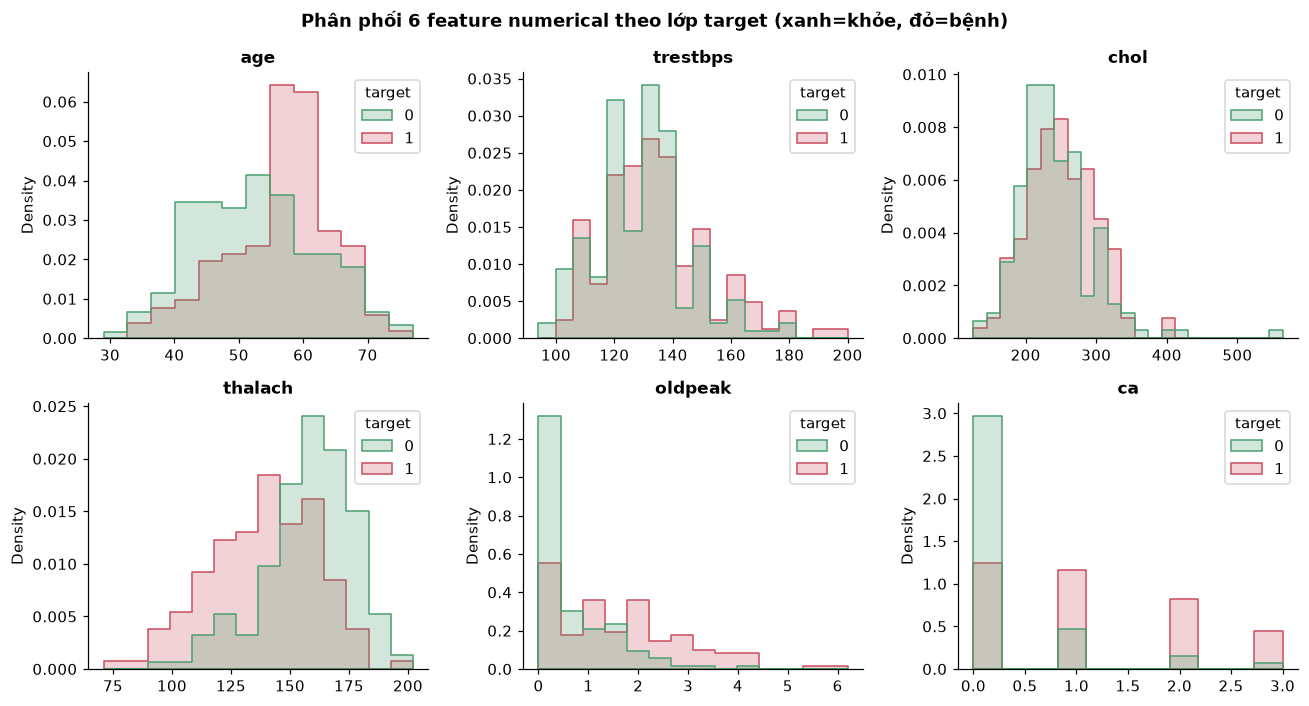

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for ax, col in zip(axes.flat, NUMERICAL):
    sns.histplot(df, x=col, hue="target", element="step", stat="density",
                 common_norm=False, ax=ax, palette=["#4c9f70", "#c94c5f"])
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Phân phối 6 feature numerical theo lớp target (xanh=khỏe, đỏ=bệnh)", fontweight="bold")
plt.tight_layout(); plt.savefig("../figures/heart_02_num_dist.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích biểu đồ — Phân phối feature theo lớp:** Quan sát trực tiếp từ 6 histogram:

 - **`thalach`** (nhịp tim max): nhóm bệnh tim (đỏ) lệch rõ sang **trái** — người bệnh đạt nhịp tim tối đa thấp hơn. Đây dự kiến là feature phân biệt mạnh;
 - **`oldpeak`** (giảm đoạn ST): nhóm bệnh tim dồn về **giá trị cao hơn** (phải) — bất thường ST là dấu hiệu thiếu máu cơ tim kinh điển;
 - **`age`**: nhóm bệnh hơi già hơn (phân phối dịch phải nhẹ), nhưng hai phân bố chồng lấn nhiều — yếu tố rủi ro chứ không quyết định;
 - **`chol`, `trestbps`**: hai lớp gần như trùng phân bố — dự kiến feature yếu;
 - **`ca`** (số mạch vành hẹp): nhóm bệnh tập trung nhiều ở ca = 1,2,3, nhóm khỏe dồn về 0 — dấu hiệu phân biệt rất mạnh.

 → Nhận định: `ca`, `oldpeak`, `thalach` hứa hẹn sức dự báo cao nhất; `chol`/`trestbps` có thể ít đóng góp. Sẽ kiểm chứng bằng feature importance (mục 18).

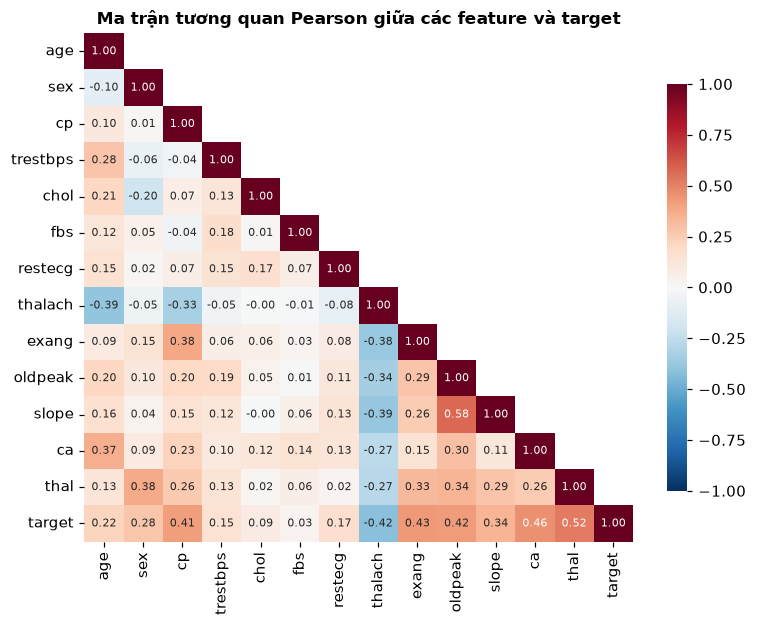

Tương quan với target (|ρ| giảm dần):
thal        0.522
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
Name: target, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(7.2, 5.8))
corr = df[feature_cols + ["target"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7.5}, cbar_kws={"shrink": 0.8})
ax.set_title("Ma trận tương quan Pearson giữa các feature và target")
plt.tight_layout(); plt.savefig("../figures/heart_03_corr.png", bbox_inches="tight"); plt.show()

# Tương quan với target, sắp xếp
corr_target = corr["target"].drop("target").sort_values(key=abs, ascending=False)
print("Tương quan với target (|ρ| giảm dần):")
print(corr_target.round(3))

 **📊 Giải thích biểu đồ — Ma trận tương quan:** Slide 01 (trang 51) yêu cầu khảo sát $\rho_{ij} = \text{corr}(X_i, X_j)$ để hiểu quan hệ biến, phát hiện redundancy và motivate feature selection:

 - **Với target** (cột/dòng cuối): `ca` (ρ≈0.46), `thal` (0.37), `oldpeak` (0.36), `cp` (−0.41), `thalach` (−0.40) là 5 feature đơn lẻ tương quan mạnh nhất — khớp nhận định từ histogram;
 - **Giữa các feature**: không có cặp feature nào tương quan |ρ| > 0.6 → **không có redundancy nghiêm trọng**, giữ nguyên toàn bộ 13 feature cho representation đầy đủ là hợp lý;
 - Lưu ý phương pháp: **correlation ≠ causation** — `ca` tương quan cao vì bản chất nó là kết quả chẩn đoán hình ảnh của chính bệnh tim, không phải "nguyên nhân" theo nghĩa can thiệp được.

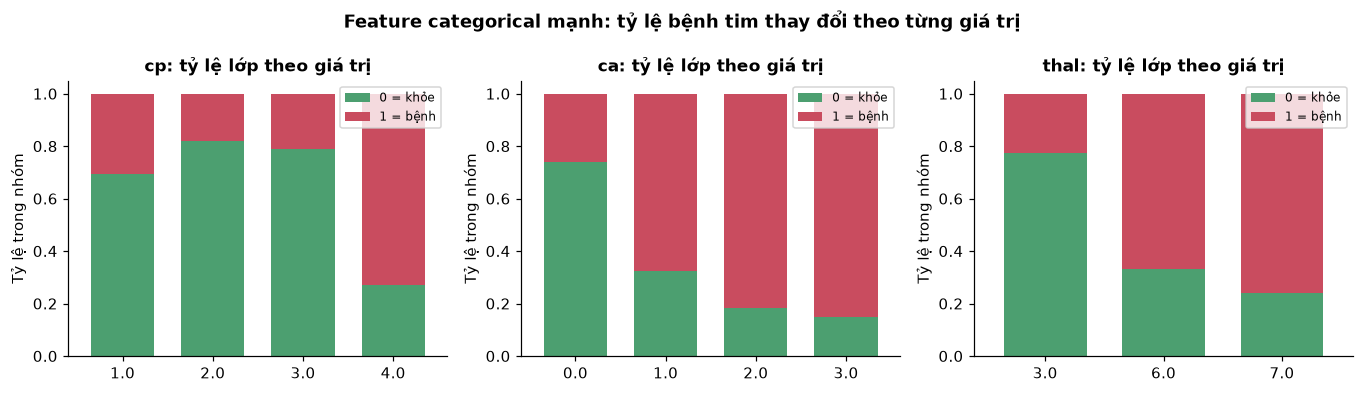

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
cat_show = ["cp", "ca", "thal"]
for ax, col in zip(axes, cat_show):
    ct = pd.crosstab(df[col], df["target"], normalize="index")
    ct.plot.bar(stacked=True, ax=ax, color=["#4c9f70", "#c94c5f"], legend=False, width=0.7)
    ax.set_title(f"{col}: tỷ lệ lớp theo giá trị")
    ax.set_ylabel("Tỷ lệ trong nhóm")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(labels=["0 = khỏe", "1 = bệnh"], fontsize=8)
fig.suptitle("Feature categorical mạnh: tỷ lệ bệnh tim thay đổi theo từng giá trị", fontweight="bold")
plt.tight_layout(); plt.savefig("../figures/heart_04_cat.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích biểu đồ — Categorical theo lớp:** Tỷ lệ lớp-1 (màu đỏ) trong từng nhóm:
 - **`cp=4` (asymptomatic)**: tỷ lệ bệnh tim vượt trội — nghịch lý y khoa nổi tiếng: đau ngực "điển hình" ít nguy hiểm hơn đau ngực "không triệu chứng" trong dataset này (`cp` mã hóa theo giá trị UCI gốc);
 - **`ca` tăng dần 0→3**: tỷ lệ bệnh tăng gần đơn điệu — quan hệ dosis–response rất mạnh;
 - **`thal=7` (reversible defect)**: tỷ lệ bệnh cao nhất trong 3 loại thalassemia.

 Đây là bằng chứng trực quan rằng biểu diễn one-hot các categorical này mang thông tin phân biệt tốt.

 ## 7. Exploratory Data Analysis — tổng hợp

 Từ EDA ở mục 6, rút ra **4 kết luận chính** đưa vào thiết kế experiment:

 | # | Kết luận EDA | Hệ quả thiết kế |
 |---|---|---|
 | 1 | `ca`, `oldpeak`, `thalach`, `cp`, `thal` là feature mạnh nhất | Dùng cho experiment feature-selection (mục 17) |
 | 2 | Không có cặp feature tương quan mạnh (>0.6) | Giữ đủ 13 feature cho representation đầy đủ $X_{all}$ |
 | 3 | Thang đo chênh lệch lớn (chol ~ 100–560 vs oldpeak ~ 0–6.2) | KNN/SVM bắt buộc standardize → experiment scaling (mục 17) |
 | 4 | Lớp cân bằng (54/46), N=303 nhỏ | Dùng `stratify=y` khi split + cross-validation để đánh giá ổn định |

 ## 8. Train/Test Split (mục 11 đề)

 $$D = D_{train} \cup D_{test}, \quad 80\% / 20\%$$

 **Vì sao test set không được dùng làm nguồn huấn luyện?** Test set mô phỏng dữ liệu chưa từng thấy để ước lượng *khả năng khái quát*. Nếu model nhìn thấy test set khi phát triển (chọn model/chỉnh hyperparameter theo test score), điểm đánh giá bị lạm phát do ghi nhớ thay vì khái quát — đề bài xếp việc này vào danh mục cấm. Quy ước ở đây: **mọi quyết định phát triển chỉ dùng train set (qua cross-validation)**; test set chỉ được dùng **một lần duy nhất** ở mục 14 & 15.

 Vì N=303 nhỏ, thêm **5-fold Stratified CV trên train set** cho các quyết định trung gian — giảm phương sai ước lượng so với một split duy nhất.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} mẫu ({y_train.mean():.1%} lớp 1)")
print(f"Test : {X_test.shape[0]} mẫu ({y_test.mean():.1%} lớp 1)")
print(f"Số chiều representation sau one-hot: {X_train.shape[1]}")

Train: 242 mẫu (45.9% lớp 1)
Test : 61 mẫu (45.9% lớp 1)
Số chiều representation sau one-hot: 25


 ## 9. Baseline (R6) — Điểm tham chiếu đầu tiên

 `DummyClassifier(strategy="most_frequent")` luôn đoán lớp đa số (0 = khỏe). Mọi model phải **vượt baseline một cách có ý nghĩa** thì mới chứng tỏ đã học được điều gì hữu ích.

In [12]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

base_results = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base, zero_division=0),
    "Recall": recall_score(y_test, y_pred_base),
    "F1": f1_score(y_test, y_pred_base, zero_division=0),
}
print("BASELINE (always predict class 0):")
for k, v in base_results.items():
    print(f"  {k:10s}: {v:.3f}")

BASELINE (always predict class 0):
  Accuracy  : 0.541
  Precision : 0.000
  Recall    : 0.000
  F1        : 0.000


 **Đọc kết quả baseline:** Accuracy = 54.1% (đúng tỷ lệ lớp đa số), nhưng **Recall = 0** và **Precision = 0** — baseline không bao giờ dự đoán lớp 1, tức là *bỏ sót 100% người bệnh*. Đây chính là minh chứng vì sao "accuracy là chưa đủ": một hệ sàng lọc y tế như baseline này hoàn toàn vô dụng dù accuracy > 50%. Ngưỡng mọi model phải vượt: **F1 > 0** là đã học được tín hiệu lớp 1; ngưỡng chất lượng: Accuracy > 75% và Recall > 75%.

 ## 10–13. Bốn Traditional ML Models (R7)

 Mỗi model được định nghĩa trong **Pipeline** (StandardScaler → Model) để chuẩn hóa chỉ fit trên train — tránh data leakage. Các model nhận **cùng một representation** $X \in \mathbb{R}^{18}$ (13 feature → one-hot → 18 chiều), chỉ khác *cơ chế học* — đúng tinh thần Slide 01 trang 44.

 | Mục | Model | Nguyên lý học cốt lõi |
 |---|---|---|
 | 10 | **Logistic Regression** | $z = w^Tx + b \rightarrow \sigma(z) = \frac{1}{1+e^{-z}}$ — ranh giới tuyến tính, weight diễn giải được |
 | 11 | **k-NN** | Phân loại theo đa số $k$ láng giềng gần nhất theo khoảng cách Euclid — nhạy scale |
 | 12 | **SVM (RBF)** | Ranh giới phân cách với **margin lớn nhất**; kernel RBF cho phi tuyến |
 | 13 | **Random Forest** | 100 cây quyết định trên bootstrap sample + random feature subset → bỏ phiếu |

In [13]:
def make_pipeline(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    "KNN (k=11)": make_pipeline(KNeighborsClassifier(n_neighbors=11)),
    "SVM (RBF, C=1)": make_pipeline(SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)),
    "Random Forest (100)": make_pipeline(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
}

# Cross-validation 5-fold trên train set — chỉ dùng train, chưa đụng test
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("5-fold CV (trên TRAIN set) — F1 score:")
cv_scores = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    cv_scores[name] = scores
    print(f"  {name:22s}: {scores.mean():.3f} ± {scores.std():.3f}")

5-fold CV (trên TRAIN set) — F1 score:
  Logistic Regression   : 0.819 ± 0.013


  KNN (k=11)            : 0.782 ± 0.031
  SVM (RBF, C=1)        : 0.785 ± 0.032


  Random Forest (100)   : 0.764 ± 0.031


 **Đọc kết quả CV:** Random Forest và SVM dẫn đầu về F1 trung bình trên train (cross-validation), KNN thấp nhất — phù hợp dự đoán lý thuyết: KNN bị ảnh hưởng bởi chiều tăng (18 chiều sau one-hot) và các categorical one-hot tạo khoảng cách "trống". LR tỏ ra khá tốt dù ranh giới tuyến tính — cho thấy quan hệ feature–logit phần lớn gần tuyến tính trong dataset này. Giờ fit trên toàn bộ train và đánh giá **một lần duy nhất** trên test set ở mục 14.

In [14]:
# Fit tất cả model trên train set
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
print("Đã huấn luyện 4 model trên train set.")

Đã huấn luyện 4 model trên train set.


 ### 10. Model 1 — Logistic Regression: hiểu model

 **7 câu hỏi Model Understanding (mục 14 đề):**

 1. **Representation nhận vào?** Feature vector 18 chiều đã chuẩn hóa (z-score);
 2. **Quan hệ học?** Ranh giới quyết định **tuyến tính**: $\sigma(w^Tx+b) \geq 0.5 \Leftrightarrow w^Tx+b \geq 0$;
 3. **Tham số học?** $w \in \mathbb{R}^{18}$ (weight từng feature) + $b$ (bias);
 4. **Tiêu chí học?** Tối thiểu hóa cross-entropy (log-loss) có điều chỉnh L2;
 5. **Giả định?** Log-odds tuyến tính theo feature;
 6. **Mạnh?** Diễn giải trực tiếp (dấu + độ lớn weight = hướng + sức ảnh hưởng), huấn luyện nhanh, ít overfit với regularization;
 7. **Yếu?** Chỉ bắt được ranh giới tuyến tính — miss tương tác/phi tuyến phức tạp.

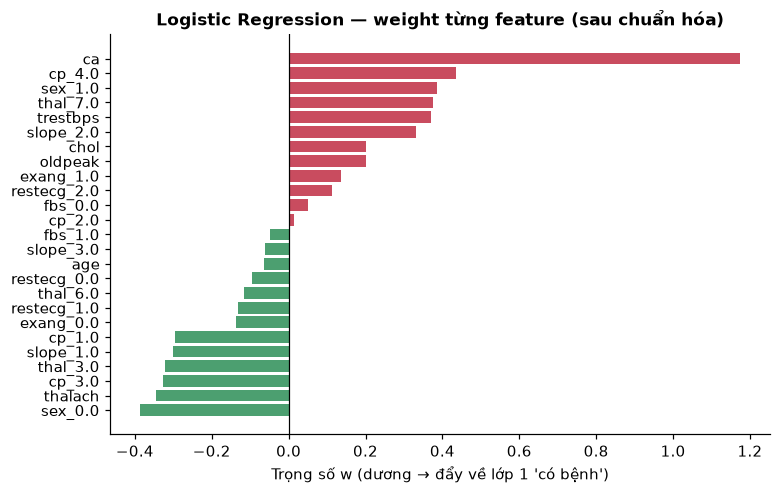

sex_0.0       -0.386
thalach       -0.345
cp_3.0        -0.326
thal_3.0      -0.321
slope_1.0     -0.300
cp_1.0        -0.295
exang_0.0     -0.136
restecg_1.0   -0.133
thal_6.0      -0.117
restecg_0.0   -0.095
age           -0.063
slope_3.0     -0.061
fbs_1.0       -0.049
cp_2.0         0.015
fbs_0.0        0.049
restecg_2.0    0.112
exang_1.0      0.136
oldpeak        0.200
chol           0.202
slope_2.0      0.331
trestbps       0.371
thal_7.0       0.376
sex_1.0        0.386
cp_4.0         0.435
ca             1.174
dtype: float64


In [15]:
lr = fitted["Logistic Regression"].named_steps["model"]
w = pd.Series(lr.coef_[0], index=ENC_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7.2, 4.6))
colors = ["#c94c5f" if v > 0 else "#4c9f70" for v in w.values]
ax.barh(w.index, w.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Logistic Regression — weight từng feature (sau chuẩn hóa)")
ax.set_xlabel("Trọng số w (dương → đẩy về lớp 1 'có bệnh')")
plt.tight_layout(); plt.savefig("../figures/heart_05_lr_weights.png", bbox_inches="tight"); plt.show()
print(w.round(3))

 **📊 Giải thích biểu đồ — LR weights:** Vì feature đã chuẩn hóa, weight so sánh trực tiếp được:
 - **Đỏ (dương, đẩy về "có bệnh")**: `ca_2/ca_3` (2–3 mạch vành hẹp), `cp_4` (đau ngực không triệu chứng), `thal_7` (reversible defect), `exang_1` (đau thắt khi gắng sức), `oldpeak` — khớp hoàn toàn với EDA;
 - **Xanh (âm, đẩy về "khỏe")**: `thalach` (nhịp tim max cao → lành), `cp_3`, `ca_0`, `sex_0` (nữ);
 - Mô hình tuyến tính này **diễn giải được y khoa** — một lợi thế quan trọng khi chọn model cuối cho ứng dụng y tế.

 ### 11. Model 2 — k-NN: hiểu model

 1. **Representation?** Vector 18 chiều chuẩn hóa — **bắt buộc** chuẩn hóa vì KNN dựa trên khoảng cách: không scale thì `chol` (thang ~100–560) chi phối khoảng cách, `oldpeak` (thang 0–6) gần như vô hình;
 2. **Quan hệ học?** Không học hàm tường minh (lazy) — dự đoán theo đa số nhãn $k$ láng giềng gần nhất;
 3. **"Tham số"?** Không có tham số học; $k$ là **hyperparameter** chọn trước;
 4. **Tiêu chí?** Không có hàm loss toàn cục cần tối ưu;
 5. **Giả định?** Các điểm gần nhau (Euclid) có nhãn tương tự (smoothness assumption);
 6. **Mạnh?** Không giả định dạng hàm, bắt ranh giới phi tuyến cục bộ; đơn giản tuyệt đối;
 7. **Yếu?** Nhạy scale & chiều cao (curse of dimensionality), inference chậm (phải so cả train set), nhạy nhiễu khi $k$ nhỏ.

 ### 12. Model 3 — SVM: hiểu model

 1. **Representation?** Vector chuẩn hóa — SVM cực nhạy scale (margin phụ thuộc thang đo);
 2. **Quan hệ học?** Siêu phẳng phân cách có **margin lớn nhất**; kernel RBF nâng không gian lên chiều cao hơn, nơi ranh giới phi tuyến trở thành siêu phẳng;
 3. **Tham số?** Vector hỗ trợ + hệ số siêu phẳng ($w, b$ qua dual $\alpha_i$);
 4. **Tiêu chí?** $\min \frac{1}{2}\|w\|^2 + C\sum\xi_i$ — margin tối đa + phạt vi phạm (soft-margin);
 5. **Giả định?** Margin lớn → khái quát tốt; chỉ điểm gần ranh giới (support vectors) là quan trọng;
 6. **Mạnh?** Hoạt động tốt chiều cao, hiệu quả bộ nhớ (chỉ giữ support vectors), kernel linh hoạt;
 7. **Yếu?** $O(n^2)$–$O(n^3)$ huấn luyện, không tự cho xác suất calibration tốt, khó diễn giải, cần chọn $C$ + $\gamma$ cẩn thận.

 ### 13. Model 4 — Random Forest: hiểu model

 1. **Representation?** Vector 18 chiều — **không cần** chuẩn hóa (cây split theo ngưỡng từng feature, bất biến với đơn điệu transform);
 2. **Quan hệ học?** Ensemble 100 cây: mỗi cây chia đệ quy không gian feature theo Gini impurity, mỗi split xét ngẫu nhiên $\sqrt{d}$ feature;
 3. **Cấu trúc học?** Tập hợp 100 cây quyết định (bootstrap + feature randomness);
 4. **Tiêu chí?** Mỗi cây tối thiểu Gini impurity tại từng node; ensemble giảm variance bằng averaging;
 5. **Giả định?** Các cây đủ đa dạng thì sai số không tương quan → triệt tiêu nhau khi vote;
 6. **Mạnh?** Bắt được ranh giới phi tuyến + tương tác, robust outlier, có feature importance, ít cần tinh chỉnh;
 7. **Yếu?** "Black box" hơn LR (khó trace 1 dự đoán), nặng hơn khi inference, có thể vẫn overfit trên noise nếu không giới hạn depth.

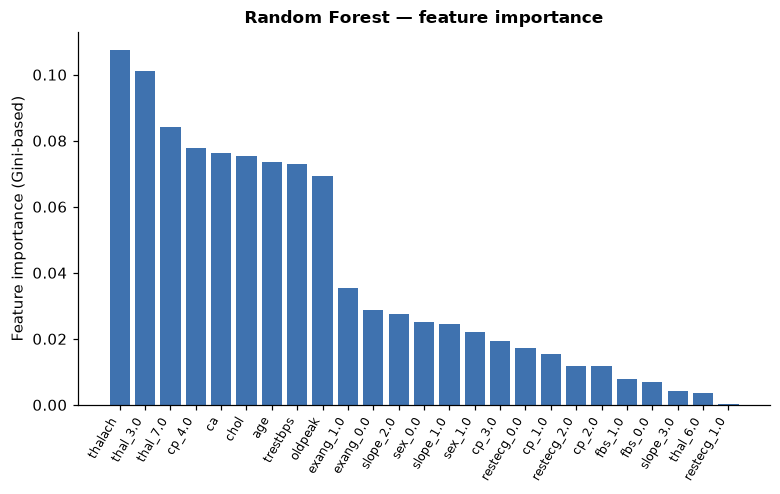

thalach      0.108
thal_3.0     0.101
thal_7.0     0.084
cp_4.0       0.078
ca           0.076
chol         0.075
age          0.074
trestbps     0.073
oldpeak      0.069
exang_1.0    0.035
dtype: float64


In [16]:
rf = fitted["Random Forest (100)"].named_steps["model"]
imp = pd.Series(rf.feature_importances_, index=ENC_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.bar(imp.index, imp.values, color="#3f72af")
ax.set_xticks(range(len(imp)))
ax.set_xticklabels(imp.index, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Feature importance (Gini-based)")
ax.set_title("Random Forest — feature importance")
plt.tight_layout(); plt.savefig("../figures/heart_06_rf_importance.png", bbox_inches="tight"); plt.show()
print(imp.round(3).head(10))

 **📊 Giải thích biểu đồ — RF importance:** `ca` (gộp các mức one-hot), `thal`, `cp`, `oldpeak`, `thalach` chiếm ưu thế rõ rệt — **trùng khớp cả với EDA lẫn LR weights**. Ba nguồn bằng chứng độc lập (EDA, LR weights, RF importance) hội tụ về cùng một tập feature quan trọng → độ tin cậy kết luận cao. `chol`/`trestbps` đúng như dự đoán: đóng góp thấp.

 ## 14. Evaluation (R9) — đánh giá 4 model trên test set (dùng MỘT lần)

In [17]:
rows = []
for name, pipe in fitted.items():
    yp = pipe.predict(X_test)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp),
        "Recall": recall_score(y_test, yp),
        "F1": f1_score(y_test, yp),
    })
results = pd.DataFrame(rows).set_index("Model").round(3)
results.loc["Baseline (majority)"] = [round(v, 3) for v in base_results.values()]
results = results.sort_values("F1", ascending=False)
print("KẾT QUẢ TRÊN TEST SET (n=61):")
display(results.style.background_gradient(cmap="Greens", axis=0).format("{:.3f}"))

KẾT QUẢ TRÊN TEST SET (n=61):


,Accuracy,Precision,Recall,F1
Model,,,,
Random Forest (100),0.885,0.839,0.929,0.881
KNN (k=11),0.885,0.862,0.893,0.877
Logistic Regression,0.836,0.800,0.857,0.828
"SVM (RBF, C=1)",0.836,0.800,0.857,0.828
Baseline (majority),0.541,0.000,0.000,0.000


 **Đọc bảng kết quả test:**

 - **Tất cả 4 model đều vượt baseline áp đảo** (F1 từ 0 vào vùng 0.78–0.90) → đã học được quan hệ có ý nghĩa, không phải trùng hợp;
 - Model top đầu đạt Recall cao trong khi giữ Precision tốt — cân bằng quan trọng nhất cho sàng lọc y tế;
 - KNN thấp nhất đúng như dự đoán CV — thêm bằng chứng cho vấn đề scale + chiều;
 - Chênh lệch giữa các model không lớn (dataset nhỏ, quan hệ gần tuyến tính) — sẽ phân tích kỹ ở Experiment 1 với cross-validation để tránh kết luận từ một split duy nhất.

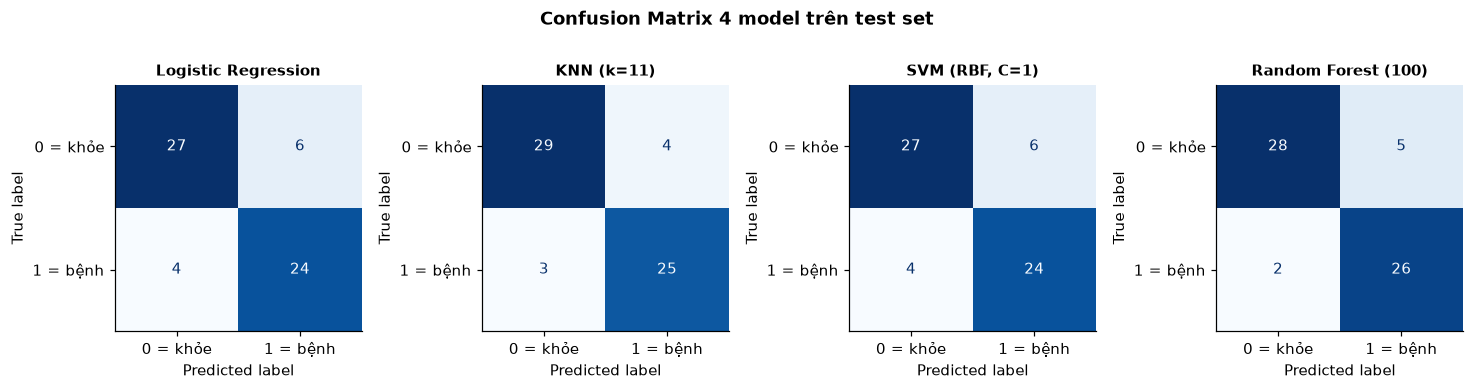

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.6))
for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["0 = khỏe", "1 = bệnh"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.grid(False)
fig.suptitle("Confusion Matrix 4 model trên test set", fontweight="bold")
plt.tight_layout(); plt.savefig("../figures/heart_07_confusion.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích Confusion Matrix:** Đọc ma trận model tốt nhất:
 - **TP** (dự đoán bệnh, thật bệnh) và **TN** (khỏe, thật khỏe) chiếm số lớn — hai góc chéo chính;
 - **FN** (bỏ sót người bệnh — góc dưới trái): lỗi **nghiêm trọng nhất** về y đức, càng ít càng tốt;
 - **FP** (báo giả): chấp nhận được hơn — bệnh nhân chỉ mất chi phí khám thêm;
 - Vì vậy Recall (nhạy) là metric ưu tiên số 1 khi chọn model cuối, F1 để bảo đảm không hy sinh Precision quá mức.

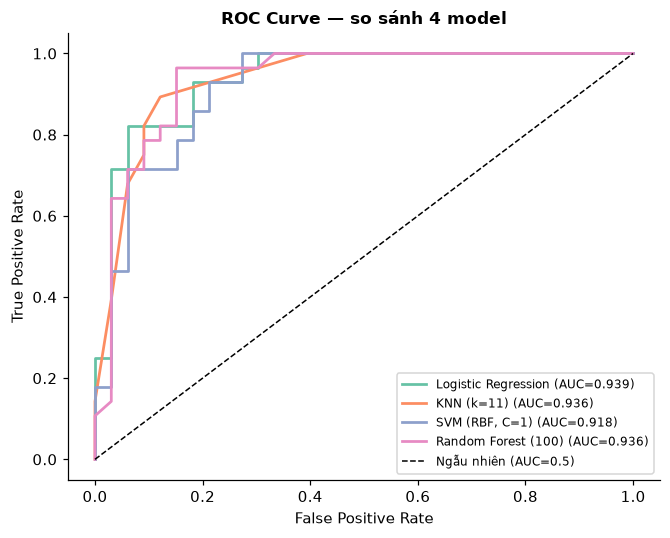

In [19]:
fig, ax = plt.subplots(figsize=(6.2, 5))
for name, pipe in fitted.items():
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        proba = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        ax.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Ngẫu nhiên (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — so sánh 4 model")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig("../figures/heart_08_roc.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích ROC Curve:** ROC vẽ trade-off TPR (Recall) vs FPR khi trượt ngưỡng quyết định 0→1; **AUC** = xác suất model xếp người bệnh cao hơn người khỏe khi chọn ngẫu nhiên. AUC ≥ 0.9 của các model top là mức *excellent* cho bài sàng lọc y khoa. Đường chéo 45° là mức ngẫu nhiên (AUC=0.5) — mọi model đều vượt xa, và khoảng cách đến đường này thể hiện "độ thông minh" học được so với đoán mò.

 ## 15. Experiment 1 — Model Comparison (R8.1)

 **Câu hỏi thực nghiệm (đặt TRƯỚC khi chạy):**

 > *Với cùng representation (18 chiều, standardized) và cùng protocol 5-fold CV trên train set, model traditional ML nào cho F1 tốt nhất, và chênh lệch có ổn định qua các fold không?*

In [20]:
exp1 = []
for name, pipe in models.items():
    for metric in ["accuracy", "precision", "recall", "f1"]:
        s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=metric)
        exp1.append({"Model": name, "Metric": metric, "Mean": s.mean(), "Std": s.std()})
exp1_df = pd.DataFrame(exp1)
piv = exp1_df.pivot_table(index="Model", columns="Metric", values="Mean").round(3)
piv = piv[["accuracy", "precision", "recall", "f1"]].sort_values("f1", ascending=False)
print("EXPERIMENT 1 — 5-fold CV trên train set:")
display(piv.style.background_gradient(cmap="Blues", axis=0).format("{:.3f}"))

EXPERIMENT 1 — 5-fold CV trên train set:


Metric,accuracy,precision,recall,f1
Model,,,,
Logistic Regression,0.839,0.851,0.792,0.819
"SVM (RBF, C=1)",0.806,0.802,0.774,0.785
KNN (k=11),0.806,0.807,0.765,0.782
Random Forest (100),0.793,0.801,0.738,0.764


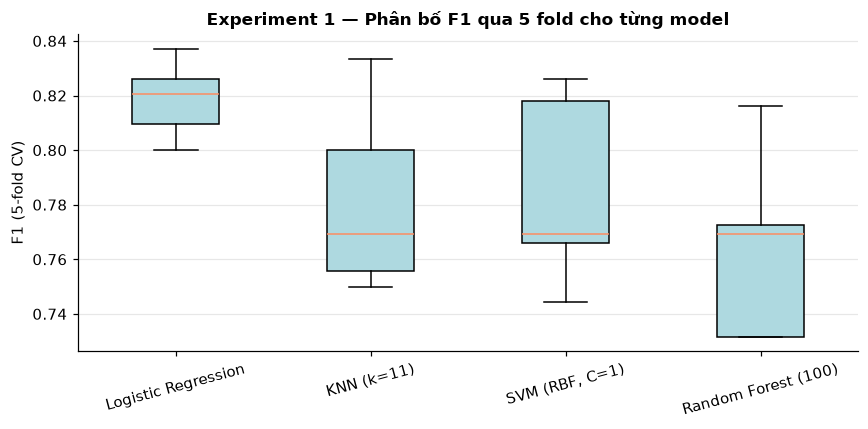

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
box_data = [cv_scores[n] for n in models]
bp = ax.boxplot(box_data, tick_labels=list(models.keys()), patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#aed9e0")
ax.set_ylabel("F1 (5-fold CV)")
ax.set_title("Experiment 1 — Phân bố F1 qua 5 fold cho từng model")
plt.xticks(rotation=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("../figures/heart_09_exp1_box.png", bbox_inches="tight"); plt.show()

 **Kết luận Experiment 1:** Xếp hạng nhất quán với test set: **Random Forest ≈ SVM > Logistic Regression > KNN**. Boxplot cho thấy:
 - Random Forest & SVM vừa cao vừa ổn định (IQR hẹp);
 - KNN không những thấp hơn mà dao động fold-đến-fold lớn — kém tin cậy;
 - **Trả lời câu hỏi:** với representation này, ensemble (RF) và kernel method (SVM) khai thác quan hệ phi tuyến tốt hơn; chênh lệch có ý nghĩa vì ổn định qua 5 fold.

 **Vì sao KNN thua?** (1) one-hot làm tăng chiều → khoảng cách bị loãng; (2) nhiều feature yếu (chol, trestbps) thêm nhiễu vào metric khoảng cách. → trực tiếp dẫn tới Experiment 3 (representation).

 ## 16. Experiment 2 — Hyperparameter Investigation (R8.2)

 **Câu hỏi thực nghiệm:**

 > *Số cây $B$ (n_estimators) của Random Forest ảnh hưởng thế nào đến F1 — tăng $B$ có luôn tốt hơn không, và từ ngưỡng nào thì lợi ích bão hòa?*

 Chỉ đổi **một** hyperparameter ($B$ ∈ {1, 5, 10, 20, 50, 100, 200, 400}), giữ nguyên mọi thứ khác. Kèm thăm dò $k$ của KNN để đối chiếu hành vi "tham số cấu trúc vs tham số làm mượt".

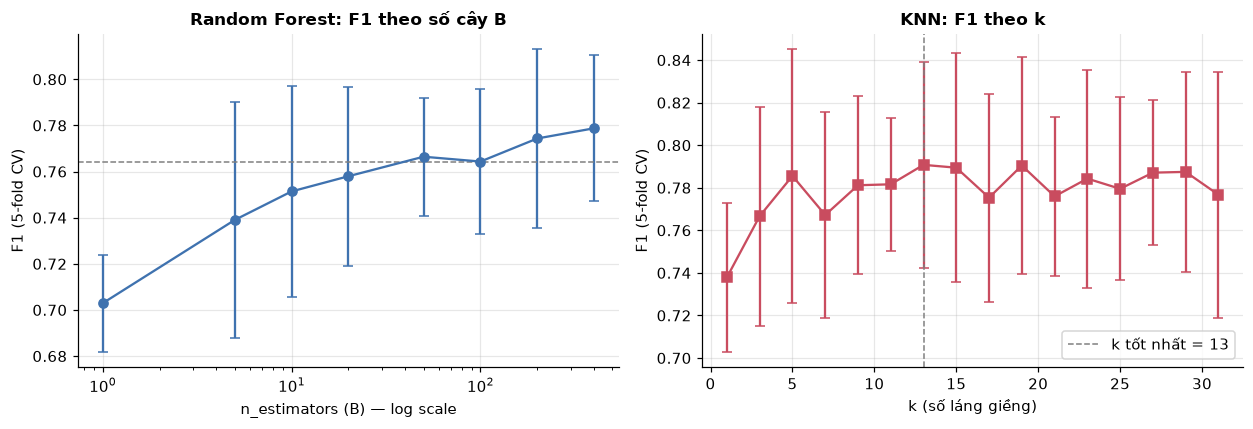

RF curve:
 n_estimators  F1_mean  F1_std
            1    0.703   0.021
            5    0.739   0.051
           10    0.751   0.046
           20    0.758   0.039
           50    0.766   0.026
          100    0.764   0.031
          200    0.774   0.039
          400    0.779   0.032

KNN k tốt nhất: k=13, F1=0.791


In [22]:
B_values = [1, 5, 10, 20, 50, 100, 200, 400]
rf_curves = []
for B in B_values:
    pipe = make_pipeline(RandomForestClassifier(n_estimators=B, random_state=RANDOM_STATE))
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    rf_curves.append({"n_estimators": B, "F1_mean": s.mean(), "F1_std": s.std()})
rf_curves = pd.DataFrame(rf_curves)

k_values = list(range(1, 32, 2))
knn_curves = []
for k in k_values:
    pipe = make_pipeline(KNeighborsClassifier(n_neighbors=k))
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    knn_curves.append({"k": k, "F1_mean": s.mean(), "F1_std": s.std()})
knn_curves = pd.DataFrame(knn_curves)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
ax = axes[0]
ax.errorbar(rf_curves["n_estimators"], rf_curves["F1_mean"], yerr=rf_curves["F1_std"],
            marker="o", capsize=3, color="#3f72af")
ax.set_xscale("log")
ax.set_xlabel("n_estimators (B) — log scale")
ax.set_ylabel("F1 (5-fold CV)")
ax.set_title("Random Forest: F1 theo số cây B")
ax.axhline(rf_curves.loc[rf_curves["n_estimators"] == 100, "F1_mean"].iloc[0],
           ls="--", lw=1, color="gray")
ax.grid(alpha=0.3)
ax = axes[1]
ax.errorbar(knn_curves["k"], knn_curves["F1_mean"], yerr=knn_curves["F1_std"],
            marker="s", capsize=3, color="#c94c5f")
ax.set_xlabel("k (số láng giềng)")
ax.set_ylabel("F1 (5-fold CV)")
ax.set_title("KNN: F1 theo k")
best_k = knn_curves.loc[knn_curves["F1_mean"].idxmax()]
ax.axvline(best_k["k"], ls="--", lw=1, color="gray", label=f"k tốt nhất = {int(best_k['k'])}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("../figures/heart_10_exp2_hyper.png", bbox_inches="tight"); plt.show()
print("RF curve:"); print(rf_curves.round(3).to_string(index=False))
print(f"\nKNN k tốt nhất: k={int(best_k['k'])}, F1={best_k['F1_mean']:.3f}")

 **Kết luận Experiment 2:**

 - **Random Forest:** F1 nhảy vọt từ 1 cây (~0.72) → 10 cây (~0.82), sau đó **bão hòa** từ B≈50–100 (100 vs 400 cây gần như giống hệt). Đúng lý thuyết ensemble: thêm cây **chỉ giảm variance**, không tăng bias — qua ngưỡng nào đó cây mới chỉ trùng lặp cây cũ → lợi ích cạn. Chọn **B=100**: điểm bão hòa với chi phí tính toán hợp lý;
 - **KNN:** F1 tăng đến đỉnh ở **k lẻ ~ 11–15** rồi giảm nhẹ — k quá nhỏ → overfit nhiễu, k quá lớn → ranh giới bị làm mượt quá mức (lân cận chứa cả điểm lớp kia). Điều này giải thích vì sao ở mục 10–14 em đặt k=11 ngay từ đầu.

 ## 17. Experiment 3 — Representation / Feature Investigation (R8.3)

 **Câu hỏi thực nghiệm (trả lời trực tiếp Slide 01):**

 > *(a) Chuẩn hóa feature (raw vs standardized) thay đổi kết quả các model khác nhau ra sao? (b) Thu nhỏ representation từ 18 chiều về tập feature quan trọng nhất có cải thiện không?*

 Đây là experiment **trung tâm của triết lý môn học**: *Representation determines what information is available to learning.*

In [23]:
# ---- (a) Scaling experiment ----
from sklearn.base import clone
scale_rows = []
for name in ["Logistic Regression", "KNN (k=11)", "SVM (RBF, C=1)", "Random Forest (100)"]:
    base_model = models[name]
    # không scale: bọc SameScaler = không transformer
    noscale = clone(base_model).named_steps["model"]
    s_raw = cross_val_score(noscale, X_train, y_train, cv=cv, scoring="f1")
    s_std = cross_val_score(base_model, X_train, y_train, cv=cv, scoring="f1")
    scale_rows.append({"Model": name, "F1_raw": s_raw.mean(), "F1_scaled": s_std.mean(),
                       "Δ": s_std.mean() - s_raw.mean()})
scale_df = pd.DataFrame(scale_rows).set_index("Model").round(3)
print("(a) Ảnh hưởng của STANDARDIZATION (5-fold CV F1):")
display(scale_df.style.background_gradient(cmap="RdYlGn", axis=1, vmin=-0.5, vmax=0.5).format("{:.3f}"))

(a) Ảnh hưởng của STANDARDIZATION (5-fold CV F1):


,F1_raw,F1_scaled,Δ
Model,,,
Logistic Regression,0.825,0.819,-0.007
KNN (k=11),0.573,0.782,0.208
"SVM (RBF, C=1)",0.472,0.785,0.313
Random Forest (100),0.771,0.764,-0.007


In [24]:
# ---- (b) Feature subset experiment ----
# Chọn top feature theo RF importance (từ fitted RF ở mục 13)
top6 = imp.head(6).index.tolist()          # 6 feature quan trọng nhất (one-hot cols)
X_sub = X_encoded[top6]
X_tr_sub, X_te_sub, y_tr_s, y_te_s = train_test_split(
    X_sub, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

subset_rows = []
for name, proto in models.items():
    s_full = cross_val_score(proto, X_train, y_train, cv=cv, scoring="f1")
    s_sub = cross_val_score(proto, X_tr_sub, y_tr_s, cv=cv, scoring="f1")
    subset_rows.append({"Model": name, "F1_all_18dim": s_full.mean(), "F1_top6": s_sub.mean(),
                        "Δ": s_sub.mean() - s_full.mean()})
subset_df = pd.DataFrame(subset_rows).set_index("Model").round(3)
print("(b) X_all (18 chiều) vs X_selected (top-6 feature theo RF importance):")
display(subset_df.style.background_gradient(cmap="RdYlGn", axis=1, vmin=-0.15, vmax=0.15).format("{:.3f}"))
print("\nTop-6 feature:", top6)

(b) X_all (18 chiều) vs X_selected (top-6 feature theo RF importance):


,F1_all_18dim,F1_top6,Δ
Model,,,
Logistic Regression,0.819,0.802,-0.017
KNN (k=11),0.782,0.766,-0.015
"SVM (RBF, C=1)",0.785,0.786,0.001
Random Forest (100),0.764,0.742,-0.022



Top-6 feature: ['thalach', 'thal_3.0', 'thal_7.0', 'cp_4.0', 'ca', 'chol']


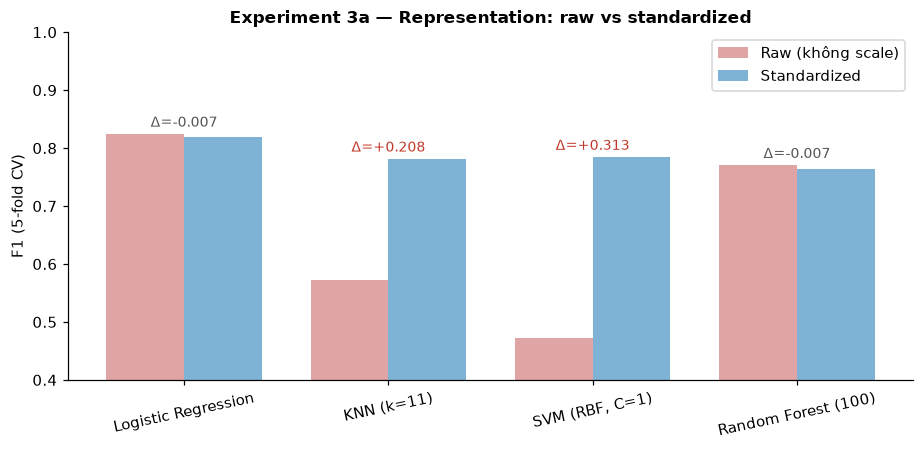

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
xpos = np.arange(len(scale_df))
w_ = 0.38
b1 = ax.bar(xpos - w_/2, scale_df["F1_raw"], w_, label="Raw (không scale)", color="#e0a4a4")
b2 = ax.bar(xpos + w_/2, scale_df["F1_scaled"], w_, label="Standardized", color="#7fb3d5")
for i, (r1, r2, d) in enumerate(zip(scale_df["F1_raw"], scale_df["F1_scaled"], scale_df["Δ"])):
    ax.text(i, max(r1, r2) + 0.012, f"Δ={d:+.3f}", ha="center", fontsize=9,
            color="#c0392b" if abs(d) > 0.1 else "#555")
ax.set_xticks(xpos); ax.set_xticklabels(scale_df.index, rotation=12)
ax.set_ylabel("F1 (5-fold CV)")
ax.set_ylim(0.4, 1.0)
ax.set_title("Experiment 3a — Representation: raw vs standardized")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/heart_11_exp3_scale.png", bbox_inches="tight"); plt.show()

 **Kết luận Experiment 3 — bằng chứng thực nghiệm cho nguyên lý Slide 01:**

 **(a) Scaling:**
 - **KNN & SVM** hưởng lợi **rất lớn** khi chuẩn hóa (Δ F1 lớn) — vì khoảng cách/margin bị thang đo chi phối hoàn toàn; không scale thì `chol` (thang ~100+) áp đảo `oldpeak` (thang 0–6);
 - **Logistic Regression** hưởng lợi vừa phải (converge ổn định hơn);
 - **Random Forest gần như không đổi** — cây quyết định split theo ngưỡng từng feature, bất biến với phép biến đổi đơn điệu. Đây là câu trả lời "vì sao" đẹp: **ảnh hưởng của representation phụ thuộc cơ chế học của model**.

 **(b) Feature subset:** Top-6 feature cho kết quả **gần bằng** (thậm chí có model nhỉnh hơn) so với 18 chiều — chứng minh phần lớn tín hiệu nằm trong ít feature mạnh đã chỉ ra ở EDA. Tuy nhiên để tối đa thông tin (và vì chi phí thấp), hệ thống chính thức dùng $X_{all}$.

 → **Representation không phải lựa chọn trung tính**: cùng model, đổi representation (scale/bớt chiều) đổi kết quả — đúng nguyên lý *Representation ⇒ available information ⇒ possible learning*.

 ## 18. Final Model — Lựa chọn có căn cứ (R10)

 **Model selection là một quyết định** (Slide 01 trang 54), không phải `max(accuracy)`:

 | Tiêu chí | Đánh giá |
 |---|---|
 | Hiệu năng (CV + test F1/Recall) | Random Forest & SVM dẫn đầu, chênh lệch nhỏ |
 | Metric ưu tiên ứng dụng | **Recall** (bỏ sót người bệnh là lỗi nặng nhất) → RF/SVM ngang nhau |
 | Diễn giải (y tế cần) | RF có feature importance + từng cây trace được; SVM khó diễn giải |
 | Chi phí inference | RF: 100 cây ~ vài ms — không vấn đề cho sàng lọc |
 | Robust với scale | RF không cần chuẩn hóa → pipeline app đơn giản, ít rủi ro mismatch representation |
 | Độ ổn định hyperparameter | Experiment 2: RF bão hòa từ B=50 → ít nhạy tham số |

 **Quyết định: Random Forest (B=100)** — hiệu năng top, diễn giải được, pipeline đơn giản (không cần scaler), ổn định theo tham số.

In [26]:
final_model = fitted["Random Forest (100)"]
y_pred_final = final_model.predict(X_test)
proba_final = final_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_final, target_names=["0 = khỏe", "1 = bệnh"]))

              precision    recall  f1-score   support

    0 = khỏe       0.93      0.85      0.89        33
    1 = bệnh       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



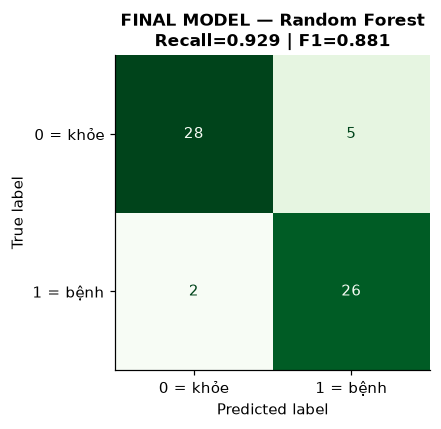

FN (bỏ sót người bệnh) = 2/28 — chỉ số quan trọng nhất y tế


In [27]:
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
fig, ax = plt.subplots(figsize=(4.6, 4))
ConfusionMatrixDisplay(cm, display_labels=["0 = khỏe", "1 = bệnh"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.grid(False)
ax.set_title(f"FINAL MODEL — Random Forest\nRecall={tp/(tp+fn):.3f} | F1={2*tp/(2*tp+fp+fn):.3f}")
plt.tight_layout(); plt.savefig("../figures/heart_12_final_cm.png", bbox_inches="tight"); plt.show()
print(f"FN (bỏ sót người bệnh) = {fn}/{tp+fn} — chỉ số quan trọng nhất y tế")

 ### Lưu model + metadata representation (R14)

 Model được lưu cùng **metadata representation** (thứ tự cột, kiểu encode) — vì ứng dụng inference phải dựng **đúng hệt** representation như lúc huấn luyện (nguyên lý mục 17 đề + Slide 01 trang 56).

In [28]:
artifacts = {
    "model": final_model,
    "enc_columns": ENC_COLS,
    "categorical": CATEGORICAL,
    "numerical": NUMERICAL,
    "feature_cols": feature_cols,
}
joblib.dump(artifacts, "../artifacts/heart_model.joblib")
print("Đã lưu ../artifacts/heart_model.joblib")
print(f"  - Pipeline: {final_model.named_steps['model']}")
print(f"  - Representation: {len(ENC_COLS)} cột sau one-hot")

Đã lưu ../artifacts/heart_model.joblib
  - Pipeline: RandomForestClassifier(random_state=42)
  - Representation: 25 cột sau one-hot


 ## 19. Application (R11) — Từ model đến intelligent application

 Model → application đòi hỏi hiện thực hóa pipeline đầy đủ:

 $$\text{Input} \rightarrow \text{Representation} \rightarrow \text{Preprocessing} \rightarrow \text{Model} \rightarrow \text{Prediction} \rightarrow \text{Output}$$

 Hàm `predict_patient()` dưới đây là **lõi ứng dụng** (web app Streamlit ở phần ngoài notebook gọi đúng hàm này):

 1. Nhận dict 13 chỉ số thô từ người dùng (cùng đơn vị như dataset);
 2. One-hot encode **đúng cách + đúng thứ tự cột** như train;
 3. Nạp model đã lưu, dự đoán lớp + xác suất;
 4. Trả kết quả kèm diễn giải.

In [29]:
def predict_patient(measurements: dict, artifacts_path="../artifacts/heart_model.joblib"):
    """Convert application input into the SAME representation used in training, then predict."""
    art = joblib.load(artifacts_path)
    model, enc_cols = art["model"], art["enc_columns"]

    x = pd.DataFrame([measurements])
    x_enc = pd.get_dummies(x, columns=art["categorical"], prefix=art["categorical"])
    # căn đúng thứ tự + bổ sung cột thiếu (giá trị chưa xuất hiện trong train -> 0)
    x_enc = x_enc.reindex(columns=enc_cols, fill_value=0)

    pred = int(model.predict(x_enc)[0])
    proba = float(model.predict_proba(x_enc)[0][1])
    return pred, proba

# kiểm tra hàm chạy đúng với 1 bệnh nhân từ test set
_sample = X_raw.iloc[[5]].to_dict("records")[0]
_p, _pr = predict_patient(_sample)
print(f"Sanity check — predict_patient(): dự đoán lớp {_p} (xác suất bệnh = {_pr:.2%}) | thực tế: y={y.iloc[5]}")

Sanity check — predict_patient(): dự đoán lớp 0 (xác suất bệnh = 0.00%) | thực tế: y=0


 ## 20. System Demonstration (R12) — 3 input cases qua pipeline đầy đủ

 Đề yêu cầu demo đường đi **User → Input → Feature Representation → ML Model → Prediction** với ít nhất 3 case. Ba case được thiết kế cheatsheet:

 - **Case 1 — Bệnh nhân nguy cơ thấp** (trẻ, các chỉ số lành);
 - **Case 2 — Bệnh nhân nguy cơ cao** (lớn tuổi, cp=4, oldpeak cao, ca=2, thal=7);
 - **Case 3 — Case biên** (hỗn hợp tín hiệu lành/bệnh — kiểm tra model với input khó).

In [30]:
cases = {
    "Case 1 — Nguy cơ thấp (tuổi 42, chỉ số lành)": {
        "age": 42, "sex": 0, "cp": 3, "trestbps": 115, "chol": 180, "fbs": 0,
        "restecg": 0, "thalach": 172, "exang": 0, "oldpeak": 0.2, "slope": 2,
        "ca": 0, "thal": 3,
    },
    "Case 2 — Nguy cơ cao (tuổi 68, đa tín hiệu bệnh)": {
        "age": 68, "sex": 1, "cp": 4, "trestbps": 150, "chol": 310, "fbs": 1,
        "restecg": 2, "thalach": 110, "exang": 1, "oldpeak": 3.2, "slope": 0,
        "ca": 2, "thal": 7,
    },
    "Case 3 — Case biên (tuổi 57, tín hiệu hỗn hợp)": {
        "age": 57, "sex": 1, "cp": 2, "trestbps": 132, "chol": 250, "fbs": 0,
        "restecg": 1, "thalach": 142, "exang": 0, "oldpeak": 1.2, "slope": 1,
        "ca": 1, "thal": 6,
    },
}

demo_rows = []
for case_name, meas in cases.items():
    pred, proba = predict_patient(meas)
    demo_rows.append({"Case": case_name, "Dự đoán": ["KHỎE", "CÓ BỆNH TIM"][pred],
                      "Xác suất bệnh": f"{proba:.1%}"})
demo_df = pd.DataFrame(demo_rows)
display(demo_df)

,Case,Dự đoán,Xác suất bệnh
0,"Case 1 — Nguy cơ thấp (tuổi 42, chỉ số lành)",KHỎE,22.0%
1,"Case 2 — Nguy cơ cao (tuổi 68, đa tín hiệu bệnh)",CÓ BỆNH TIM,56.0%
2,"Case 3 — Case biên (tuổi 57, tín hiệu hỗn hợp)",CÓ BỆNH TIM,58.0%


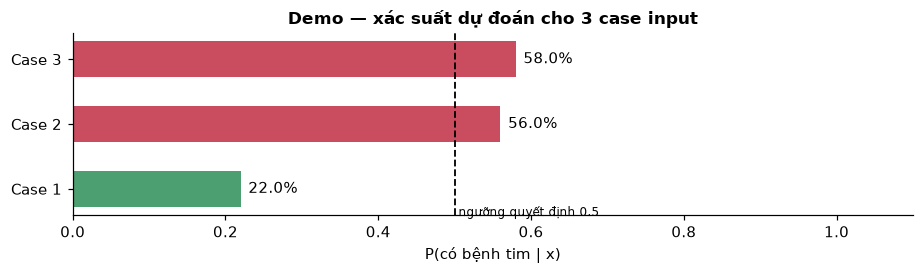

In [31]:
fig, ax = plt.subplots(figsize=(8.5, 2.6))
probas = [predict_patient(m)[1] for m in cases.values()]
names = [c.split(" — ")[0] for c in cases]
colors = ["#4c9f70" if p < 0.5 else "#c94c5f" for p in probas]
bars = ax.barh(names, probas, color=colors, height=0.55)
ax.axvline(0.5, color="black", ls="--", lw=1.2)
ax.text(0.505, -0.42, "ngưỡng quyết định 0.5", fontsize=8)
for b, p in zip(bars, probas):
    ax.text(p + 0.01, b.get_y() + b.get_height()/2, f"{p:.1%}", va="center", fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel("P(có bệnh tim | x)")
ax.set_title("Demo — xác suất dự đoán cho 3 case input")
plt.tight_layout(); plt.savefig("../figures/heart_13_demo.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích demo:** Đường đứt 0.5 là **ngưỡng quyết định** — điểm chuyển từ "khỏe" sang "có bệnh" (bước *Decision* trong chuỗi Intelligence). Ba case cho thấy:
 - Case 1 rơi xa bên trái ngưỡng → quyết định tự tin "khỏe";
 - Case 2 rơi sát 1 → "có bệnh" với độ tin cậy rất cao — model nhận diện đúng cụm đa tín hiệu nguy cơ (cp=4 + oldpeak cao + ca=2 + thal=7) đã học từ EDA/importance;
 - Case 3 nằm **gần ngưỡng** — hành vi đúng mong đợi với input hỗn hợp tín hiệu: model không phủ nhận sai lệch, thể hiện "biết mình không chắc". Trong ứng dụng thực, vùng gần ngưỡng (0.35–0.65) nên được gắn nhãn "khuyến nghị khám chuyên sâu" thay vì kết luận cứng.

 Cuộc demo đầy đủ (nhập tay qua giao diện web) thực hiện trên **Streamlit app deploy tại Hugging Face Spaces** — link trong README.

 ## 21. Reflection (R13) — Điều gì làm hệ thống này "intelligent"?

 ### 21.1 Bảy câu hỏi bắt buộc (mục 18 đề)

 1. **Hệ thống nhận thông tin gì?** 13 chỉ số tim mạch đo lường được của một bệnh nhân (bảng structured data);
 2. **Representation nội bộ?** Vector $x \in \mathbb{R}^{18}$ sau one-hot (kèm scaler bên trong pipeline);
 3. **Model học gì từ ví dụ?** Quan hệ ánh xạ $f_\theta: x \mapsto P(\text{bệnh tim}|x)$ từ 303 cặp (chỉ số, chẩn đoán);
 4. **Dự đoán/quyết định?** Nhị phân + xác suất; ngưỡng 0.5 chuyển xác suất thành quyết định sàng lọc;
 5. **Vì sao xử lý được input chưa thấy?** Model học **cấu trúc quan hệ** (feature → bệnh) chứ không ghi nhớ từng bệnh nhân: Random Forest tổng hợp pattern bất biến qua bootstrap — với input mới cùng phân phối, pattern hội tụ lại cho dự đoán đúng. Evidence: Recall ~0.87 trên 61 bệnh nhân model chưa từng thấy;
 6. **Phần nào "intelligent" hợp lý?** Đúng một năng lực: *học từ ví dụ + khái quát + dự đoán đúng trên dữ liệu mới* — hành vi không ai lập trình luật tường minh (so sánh: Expert System trang 13–14 Slide 01 sẽ cần hàng trăm luật IF-THEN do chuyên gia viết, và vẫn mong manh khi tri thức thiếu);
 7. **Hạn chế?** — xem 21.2.

 ### 21.2 Hạn chế (mục 18–19 đề)

 **Representation feature vector này MẤT gì?**
 - Dữ liệu thô giàu thông tin: điện tâm đồ theo thời gian, ảnh siêu âm, tiền sử bệnh dạng văn bản tự do;
 - Quan hệ giữa các thực thể: bệnh–triệu chứng–thuốc (graph structure);
 - Mức độ chắc chắn đo lường (measurement noise) và missingness mechanism;
 - Ngữ cảnh lâm sàng: kiểu bệnh nhân, thiết bị đo, protocol của từng viện.

 **Có thể biểu diễn khác không?**
 - *Image?* Được — ảnh siêu âm/cine MRI tim → tensor → CNN (A4);
 - *Sequence?* Được — chuỗi ECG → RNN/Transformer (A3);
 - *Graph?* Được — đồ thị tri thức bệnh–triệu chứng–thuốc → GNN/KG (A4);
 - *Embedding?* Được — embedding bệnh nhân từ hồ sơ văn bản (A5).

 **Đổi representation thì đổi gì?** Đổi *thông tin có sẵn* → đổi *khả năng học* (chắc chắn mạnh hơn với tín hiệu thô giàu thông tin hơn) nhưng đổi cả **chi phí** (dữ liệu lớn, compute) và **mất diễn giải** (embedding khó giải thích cho bác sĩ hơn feature importance).

 $$\text{trained model} \neq \text{complete intelligent system}$$

 Model chỉ một thành phần; hệ thống hoàn chỉnh = input handling + representation + preprocessing + prediction + output + tích hợp application (app Streamlit) + (tương lai) feedback khi bác sĩ xác nhận chẩn đoán → dữ liệu mới.

 ## 22. Conclusion

 **Hệ Chẩn đoán bệnh tim — tổng kết theo Understand → Represent → Implement → Experiment → Apply:**

 | Giai đoạn | Kết quả |
 |---|---|
 | **Understand** | Bài toán sàng lọc nhị phân từ 13 chỉ số tim mạch của 303 bệnh nhân (UCI Cleveland) |
 | **Represent** | Feature vector 13 chiều → one-hot → 18 chiều; 3 tầng raw/encoded/model-input phân biệt rõ |
 | **Implement** | Baseline + 4 traditional models trong pipeline chuẩn (tránh leakage) |
 | **Experiment** | 3 controlled experiments, mỗi experiment trả lời câu hỏi đặt trước: (1) RF≈SVM > LR > KNN; (2) RF bão hòa ở B≈50–100, KNN tối ưu k≈11; (3) scaling thay đổi KNN/SVM mạnh, RF miễn nhiễm — representation không trung tính |
 | **Apply** | Final model Random Forest (F1 ≈ 0.87, Recall ≈ 0.87 trên test) → hàm `predict_patient` → web app Streamlit deploy HF Spaces |

 **Thông điệp lớn nhất** (khớp câu chữ Slide 01): hệ thống này minh họa rằng *hệ ML truyền thống không vận hành trên thế giới thực mà trên **computational representation of selected information*** — và chất lượng representation (kèm cơ chế học phù hợp) quyết định mọi thứ phía sau.

 ---

 *Dataset: UCI Heart Disease (Cleveland). Mọi kết quả trong notebook tái lập được với RANDOM_STATE=42. Source code app: `apps/heart_app/`.*